In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="darkgrid")
print("All libraries loaded ✅")

All libraries loaded ✅


In [14]:
df = pd.read_csv("train.csv", encoding="latin1")

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
df.head()

Shape: (9800, 18)

Columns:
 ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [15]:
# Check missing values
print("Missing Values:\n", df.isnull().sum())

# Basic statistics
print("\nBasic Stats:")
df.describe()

Missing Values:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Basic Stats:


,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [20]:
# Convert date columns to proper format
df["Order Date"] = pd.to_datetime(df["Order Date"], format='%d/%m/%Y')
df["Ship Date"] = pd.to_datetime(df["Ship Date"],  format='%d/%m/%Y')

# Extract useful columns from date
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Month Name"] = df["Order Date"].dt.strftime("%b")

print("Data cleaned ✅")
print(df[["Order Date", "Order Year", "Order Month", "Order Month Name"]].head())

Data cleaned ✅
  Order Date  Order Year  Order Month Order Month Name
0 2017-11-08        2017           11              Nov
1 2017-11-08        2017           11              Nov
2 2017-06-12        2017            6              Jun
3 2016-10-11        2016           10              Oct
4 2016-10-11        2016           10              Oct


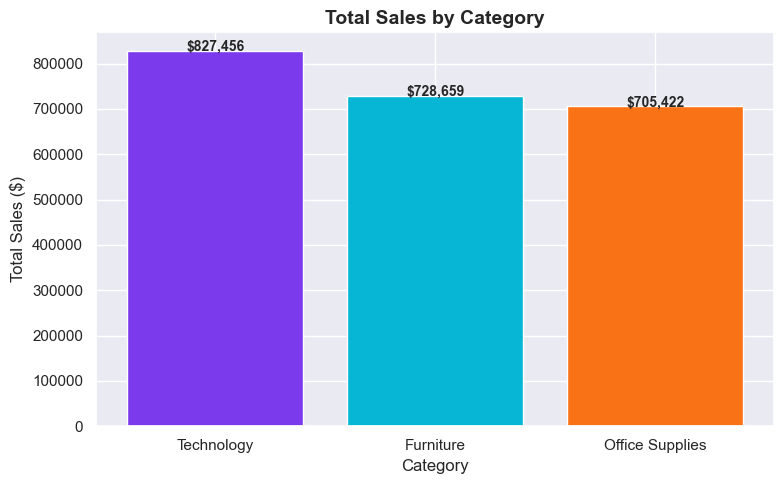

Chart 1 saved ✅


In [21]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
bars = plt.bar(category_sales.index, category_sales.values,
               color=["#7C3AED", "#06B6D4", "#F97316"])
plt.title("Total Sales by Category", fontsize=14, fontweight="bold")
plt.ylabel("Total Sales ($)")
plt.xlabel("Category")
for bar, val in zip(bars, category_sales.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 500,
             f"${val:,.0f}", ha="center", fontweight="bold", fontsize=10)
plt.tight_layout()
plt.savefig("charts/sales_by_category.png", dpi=150)
plt.show()

print("Chart 1 saved ✅")

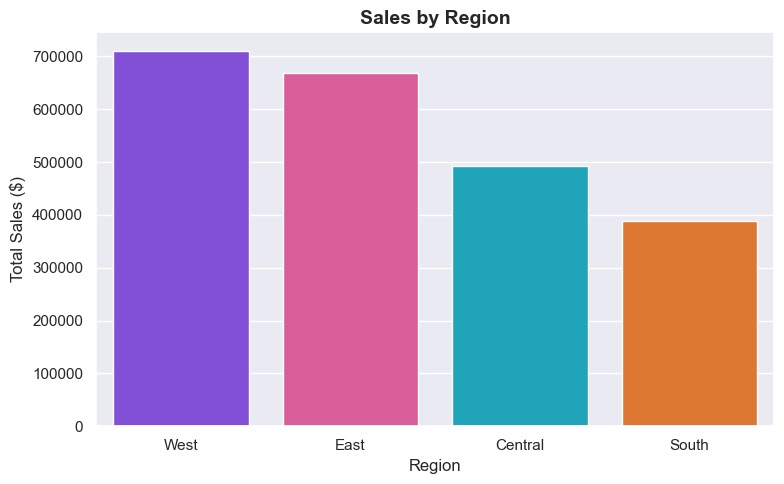

Chart 2 saved ✅


In [22]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=region_sales.index, y=region_sales.values,
            palette=["#7C3AED","#EC4899","#06B6D4","#F97316"])
plt.title("Sales by Region", fontsize=14, fontweight="bold")
plt.ylabel("Total Sales ($)")
plt.xlabel("Region")
plt.tight_layout()
plt.savefig("charts/sales_by_region.png", dpi=150)
plt.show()

print("Chart 2 saved ✅")

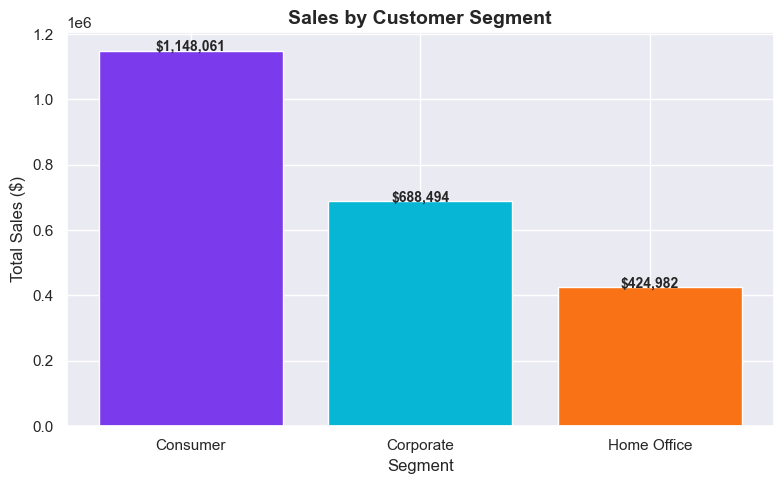

Chart 3 saved ✅


In [23]:
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
colors = ["#7C3AED", "#06B6D4", "#F97316"]
bars = plt.bar(segment_sales.index, segment_sales.values, color=colors)
plt.title("Sales by Customer Segment", fontsize=14, fontweight="bold")
plt.ylabel("Total Sales ($)")
plt.xlabel("Segment")
for bar, val in zip(bars, segment_sales.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 300,
             f"${val:,.0f}", ha="center", fontweight="bold", fontsize=10)
plt.tight_layout()
plt.savefig("charts/sales_by_segment.png", dpi=150)
plt.show()

print("Chart 3 saved ✅")

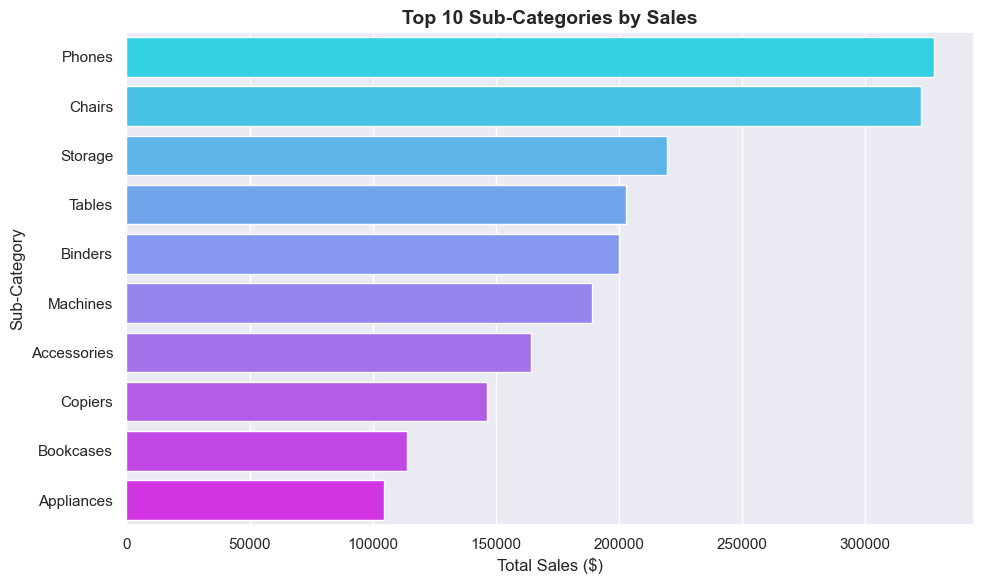

Chart 4 saved ✅


In [24]:
sub_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=sub_sales.values, y=sub_sales.index, palette="cool")
plt.title("Top 10 Sub-Categories by Sales", fontsize=14, fontweight="bold")
plt.xlabel("Total Sales ($)")
plt.tight_layout()
plt.savefig("charts/top_subcategories.png", dpi=150)
plt.show()

print("Chart 4 saved ✅")

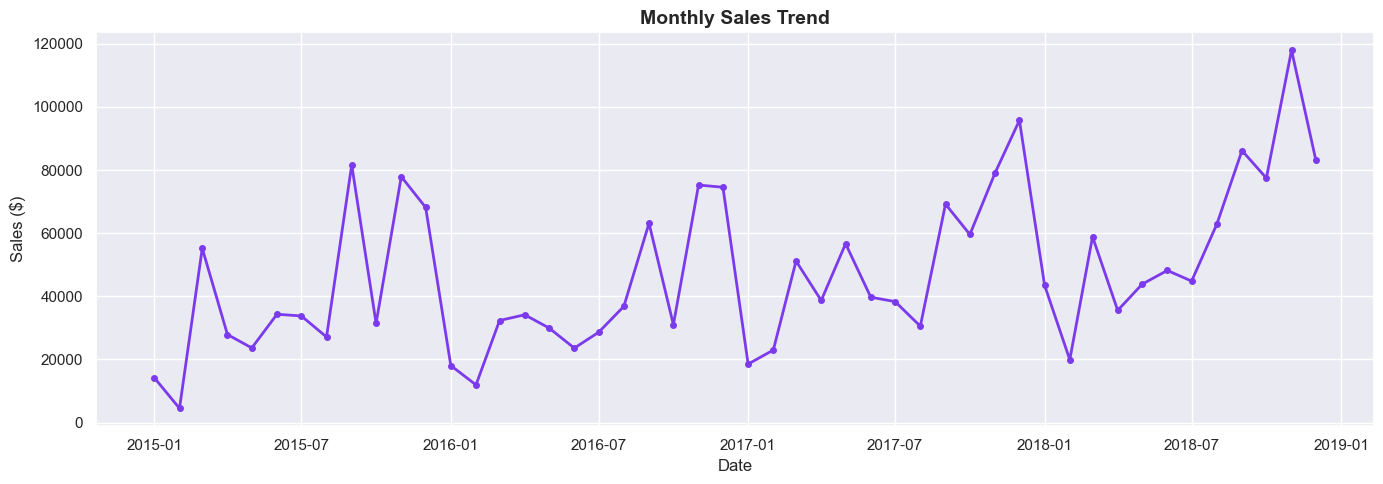

Chart 5 saved ✅


In [25]:
monthly_sales = df.groupby(["Order Year","Order Month"])["Sales"].sum().reset_index()
monthly_sales["Date"] = pd.to_datetime(
    monthly_sales[["Order Year","Order Month"]]
    .assign(day=1)
    .rename(columns={"Order Year":"year","Order Month":"month"})
)

plt.figure(figsize=(14,5))
plt.plot(monthly_sales["Date"], monthly_sales["Sales"],
         color="#7C3AED", linewidth=2, marker="o", markersize=4)
plt.title("Monthly Sales Trend", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.tight_layout()
plt.savefig("charts/monthly_sales_trend.png", dpi=150)
plt.show()

print("Chart 5 saved ✅")

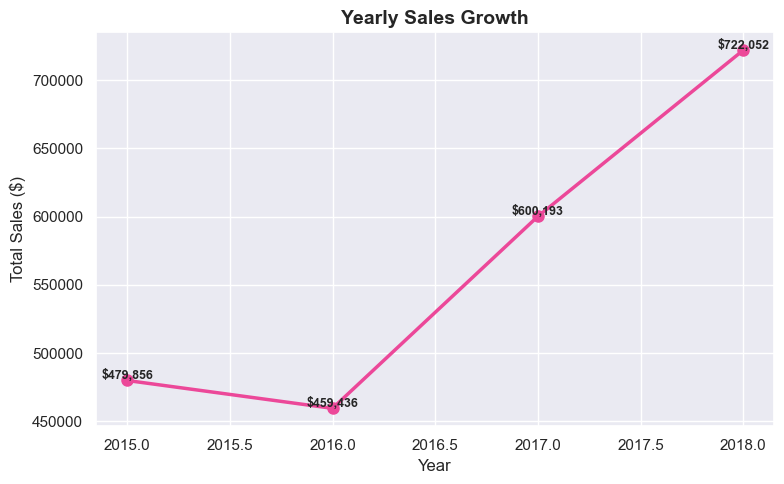

Chart 6 saved ✅


In [26]:
yearly_sales = df.groupby("Order Year")["Sales"].sum()

plt.figure(figsize=(8,5))
plt.plot(yearly_sales.index, yearly_sales.values,
         marker="o", linewidth=2.5, color="#EC4899", markersize=8)
for x, y in zip(yearly_sales.index, yearly_sales.values):
    plt.text(x, y + 1000, f"${y:,.0f}", ha="center", fontweight="bold", fontsize=9)
plt.title("Yearly Sales Growth", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.savefig("charts/yearly_growth.png", dpi=150)
plt.show()

print("Chart 6 saved ✅")

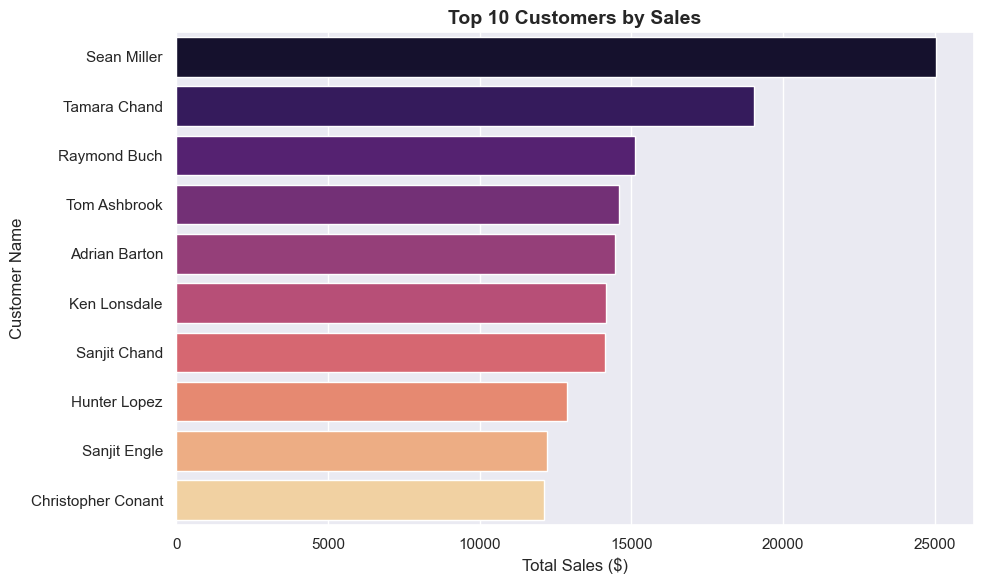

Chart 7 saved ✅


In [27]:
top_customers = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_customers.values, y=top_customers.index, palette="magma")
plt.title("Top 10 Customers by Sales", fontsize=14, fontweight="bold")
plt.xlabel("Total Sales ($)")
plt.tight_layout()
plt.savefig("charts/top_customers.png", dpi=150)
plt.show()

print("Chart 7 saved ✅")

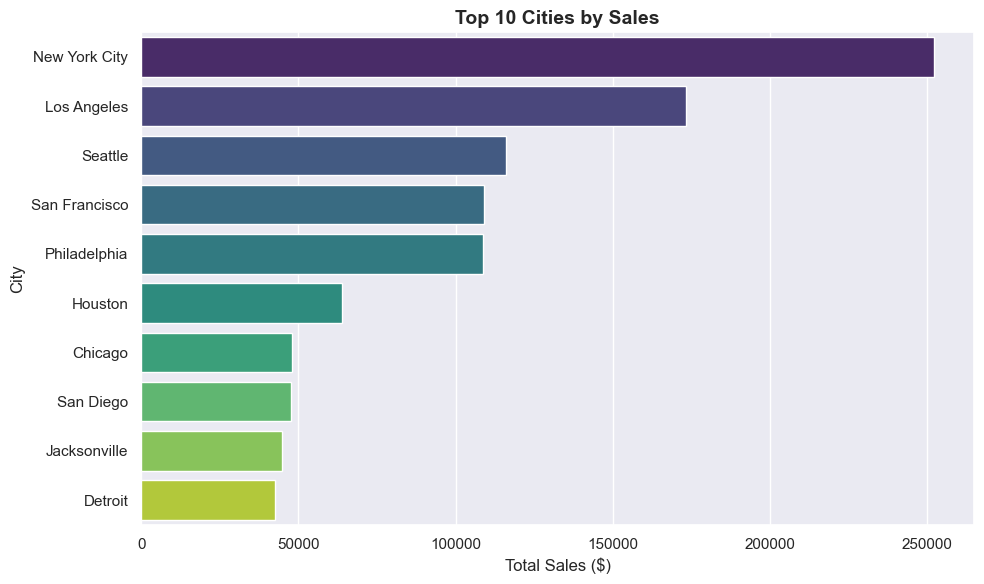

Chart 8 saved ✅


In [28]:
top_cities = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_cities.values, y=top_cities.index, palette="viridis")
plt.title("Top 10 Cities by Sales", fontsize=14, fontweight="bold")
plt.xlabel("Total Sales ($)")
plt.tight_layout()
plt.savefig("charts/top_cities.png", dpi=150)
plt.show()

print("Chart 8 saved ✅")

In [29]:
print("=" * 55)
print("📊 SUPERSTORE BUSINESS INSIGHTS")
print("=" * 55)

print(f"\n💰 Total Revenue: ${df['Sales'].sum():,.2f}")
print(f"📦 Total Orders: {df['Order ID'].nunique()}")
print(f"👥 Total Customers: {df['Customer ID'].nunique()}")
print(f"🏙️  Total Cities: {df['City'].nunique()}")

print(f"\n🏆 Best Category: {df.groupby('Category')['Sales'].sum().idxmax()}")
print(f"🌍 Best Region: {df.groupby('Region')['Sales'].sum().idxmax()}")
print(f"👤 Best Segment: {df.groupby('Segment')['Sales'].sum().idxmax()}")
print(f"🏅 Top Customer: {df.groupby('Customer Name')['Sales'].sum().idxmax()}")
print(f"🏙️  Top City: {df.groupby('City')['Sales'].sum().idxmax()}")
print(f"📅 Best Year: {df.groupby('Order Year')['Sales'].sum().idxmax()}")
print(f"📅 Best Month: {df.groupby('Order Month Name')['Sales'].sum().idxmax()}")
print("=" * 55)

📊 SUPERSTORE BUSINESS INSIGHTS

💰 Total Revenue: $2,261,536.78
📦 Total Orders: 4922
👥 Total Customers: 793
🏙️  Total Cities: 529

🏆 Best Category: Technology
🌍 Best Region: West
👤 Best Segment: Consumer
🏅 Top Customer: Sean Miller
🏙️  Top City: New York City
📅 Best Year: 2018
📅 Best Month: Nov


## 📊 Key Business Insights

1. **Technology is the top category** — highest revenue across all years
2. **Consumer segment leads** — biggest buyer group on the platform
3. **West region dominates** — strongest market by total sales
4. **Sales grow every year** — consistent upward trend from 2015–2018
5. **Top 10 customers drive significant revenue** — high value clients
6. **New York City is #1 city** by total sales volume
7. **Nov is peak month** — plan campaigns around it

In [30]:
import os

charts = os.listdir("charts")
print(f"Total charts saved: {len(charts)}")
for chart in charts:
    print(f"  ✅ {chart}")

Total charts saved: 8
  ✅ monthly_sales_trend.png
  ✅ sales_by_category.png
  ✅ sales_by_region.png
  ✅ sales_by_segment.png
  ✅ top_cities.png
  ✅ top_customers.png
  ✅ top_subcategories.png
  ✅ yearly_growth.png
